# WikiNews NLP Project — Topic Classification

This notebook builds a supervised text classification model to predict the most appropriate news category for WikiNews articles.

The main goals are to:

- load the balanced classification dataset,
- split data into training and test sets,
- transform article text using TF-IDF,
- train a Linear Support Vector Classifier,
- evaluate accuracy, precision, recall, and F1-score,
- inspect the confusion matrix,
- review example predictions and misclassified articles,
- save topic prediction results for the final report.

## 1. Imports and Data Loading

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path("..").resolve()

In [19]:
DATA_PATH = (
    PROJECT_ROOT
    / "data/processed/classification_dataset.csv"
)

classification_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", classification_df.shape)
print("\nCategory distribution:")
print(
    classification_df[
        "primary_category"
    ].value_counts()
)

Dataset shape: (1044, 6)

Category distribution:
primary_category
Economy and business      261
Politics and conflicts    261
Science and technology    261
Sports                    261
Name: count, dtype: int64


In [20]:
classification_df[
    [
        "title",
        "primary_category",
        "word_count",
    ]
].head()

,title,primary_category,word_count
0,Apple releases program to limit iPod volume,Economy and business,178
1,French fashion designer Yves Saint Laurent dea...,Economy and business,229
2,Japan's economy sees biggest decline since 1974,Economy and business,200
3,"Auto parts maker Delphi plans to cut 8,500 job...",Economy and business,196
4,Greek workers strike over austerity measures,Economy and business,231


## 2. Train-Test Split

The article text is used as the input feature, while the single selected WikiNews category is used as the target label.

A stratified split is used so that all four categories remain balanced in both the training and test sets.

In [21]:
X = classification_df["text"]
y = classification_df["primary_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training articles:", len(X_train))
print("Test articles:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training articles: 835
Test articles: 209

Training distribution:
primary_category
Economy and business      209
Sports                    209
Politics and conflicts    209
Science and technology    208
Name: count, dtype: int64

Test distribution:
primary_category
Science and technology    53
Sports                    52
Politics and conflicts    52
Economy and business      52
Name: count, dtype: int64


## 3. TF-IDF + LinearSVC Classification Pipeline

A classical NLP baseline is used:

1. TF-IDF transforms article text into weighted unigram and bigram features.
2. LinearSVC learns decision boundaries between the four news categories.

In [22]:
classifier = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                max_features=20000,
                min_df=2,
            ),
        ),
        (
            "classifier",
            LinearSVC(),
        ),
    ]
)

classifier

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",20000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be 

In [23]:
classifier.fit(
    X_train,
    y_train,
)

print("Model training complete.")

Model training complete.


## 4. Model Evaluation

In [24]:
y_pred = classifier.predict(
    X_test
)

print("Predictions generated:", len(y_pred))

Predictions generated: 209


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred,
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0,
    )
)

print(f"Accuracy: {accuracy:.3f}")
print(f"Macro precision: {precision:.3f}")
print(f"Macro recall: {recall:.3f}")
print(f"Macro F1-score: {f1:.3f}")

Accuracy: 0.909
Macro precision: 0.910
Macro recall: 0.909
Macro F1-score: 0.910


In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0,
    )
)

                        precision    recall  f1-score   support

  Economy and business       0.84      0.88      0.86        52
Politics and conflicts       0.92      0.90      0.91        52
Science and technology       0.92      0.91      0.91        53
                Sports       0.96      0.94      0.95        52

              accuracy                           0.91       209
             macro avg       0.91      0.91      0.91       209
          weighted avg       0.91      0.91      0.91       209



## 5. Confusion Matrix

The confusion matrix shows which news categories are predicted correctly and where the model confuses semantically related topics.

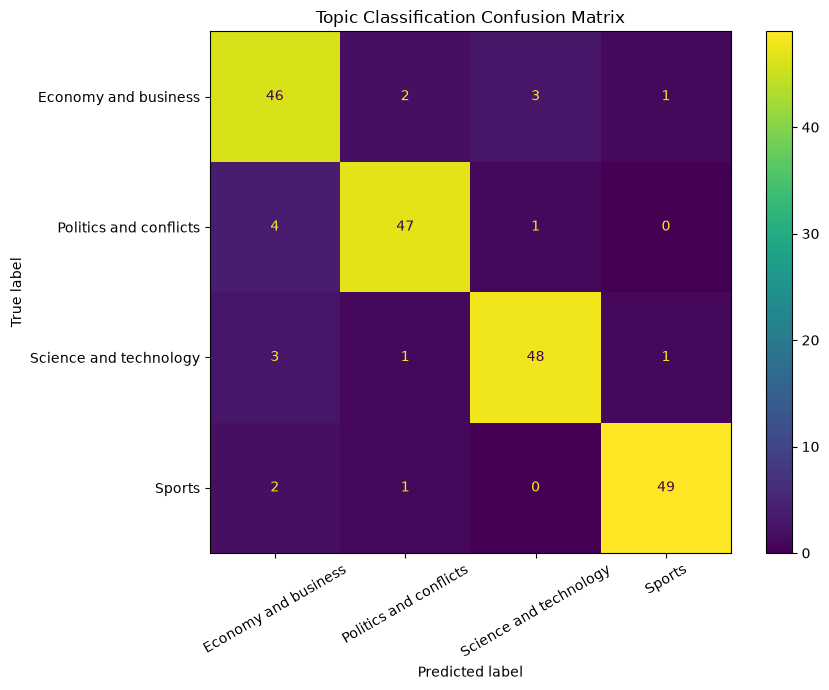

In [27]:
labels = sorted(
    classification_df[
        "primary_category"
    ].unique()
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

display.plot(
    ax=ax,
    xticks_rotation=30,
    values_format="d",
)

plt.title(
    "Topic Classification Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 6. Example Predictions

Example predictions are inspected to verify that the predicted topic labels are logical and consistent with the article content.

In [28]:
prediction_results = classification_df.loc[
    X_test.index,
    [
        "pageid",
        "title",
        "primary_category",
        "text",
    ],
].copy()

prediction_results["predicted_category"] = y_pred

prediction_results["correct"] = (
    prediction_results["primary_category"]
    == prediction_results["predicted_category"]
)

prediction_results[
    [
        "title",
        "primary_category",
        "predicted_category",
        "correct",
    ]
].head(15)

,title,primary_category,predicted_category,correct
857,Kimi Räikkönen wins 2007 Australian Grand Prix,Sports,Sports,True
829,2008 Tour de Taiwan Stage 5: Shawn Milne threa...,Sports,Sports,True
851,Draw results for UEFA Euro 2008 announced,Sports,Sports,True
460,Serbian protesters try to storm Parliament; fo...,Politics and conflicts,Politics and conflicts,True
449,5 reporters hurt in conflict over ex-President...,Politics and conflicts,Politics and conflicts,True
966,Houston Astros win 2005 National League baseba...,Sports,Sports,True
240,US unemployment rate reaches 9.8%,Economy and business,Economy and business,True
102,US air carrier Spirit Airlines announces $45 c...,Economy and business,Economy and business,True
235,Nobel Peace Prize to Muhammad Yunus and the Gr...,Economy and business,Science and technology,False
511,"Travel ban 2.0 exempts Iraqis, U.S. permanent ...",Politics and conflicts,Politics and conflicts,True


## 7. Misclassified Articles

Misclassified examples are inspected to understand where topic overlap or ambiguous article content causes classification errors.

In [29]:
misclassified = prediction_results.loc[
    ~prediction_results["correct"]
].copy()

print(
    "Misclassified articles:",
    len(misclassified),
)

misclassified[
    [
        "title",
        "primary_category",
        "predicted_category",
    ]
].head(20)

Misclassified articles: 19


,title,primary_category,predicted_category
235,Nobel Peace Prize to Muhammad Yunus and the Gr...,Economy and business,Science and technology
380,Disputed island disappears beneath sea on Indi...,Politics and conflicts,Economy and business
364,Egypt announces Internet crime initiative,Politics and conflicts,Science and technology
678,Suspended sentence for Sasser worm author,Science and technology,Economy and business
556,"""PGR4"" pre-launch in Taiwan: TOP Drivers' Derby",Science and technology,Sports
1,French fashion designer Yves Saint Laurent dea...,Economy and business,Sports
861,"Chopper knocks Austrian gondola off cables, ki...",Sports,Politics and conflicts
812,Slovenian alpinist rescued from Himalayan peak,Sports,Economy and business
320,Antiglobalization protestors march near site o...,Politics and conflicts,Economy and business
250,Philippine President calls for resignation of ...,Economy and business,Politics and conflicts


In [30]:
for _, row in misclassified.head(10).iterrows():
    print("=" * 90)
    print("TITLE:", row["title"])
    print("ACTUAL:", row["primary_category"])
    print("PREDICTED:", row["predicted_category"])
    print("\nTEXT PREVIEW:")
    print(row["text"][:700])
    print()

TITLE: Nobel Peace Prize to Muhammad Yunus and the Grameen Bank
ACTUAL: Economy and business
PREDICTED: Science and technology

TEXT PREVIEW:
The microcredit Grameen Bank and its creator, Muhammad Yunus, are jointly awarded the Nobel Peace Prize "for their efforts to create economic and social development from below." Most people were expecting the founder to be nominated for the Economics Nobel prize but the Norwegian Nobel Institute decided to award him the Peace Prize for his attempt to destroy poverty, emphasizing women who have to "struggle against repressive social and economic conditions". Yunus, from Bangladesh, said "We want the same kind of unity in politics like the unity that has been created by the Nobel prize award," at a press conference at the bank's office in the suburbs of the Bangladeshee capital, Dhaka. In 2005

TITLE: Disputed island disappears beneath sea on India-Bangladesh border
ACTUAL: Politics and conflicts
PREDICTED: Economy and business

TEXT PREVIEW:
The i

## 8. Save Topic Prediction Results

In [31]:
PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "data/processed/topic_predictions.csv"
)

prediction_results.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

print("Saved:", PREDICTIONS_PATH)
print("Shape:", prediction_results.shape)

Saved: /workspaces/rigoel-NLP.AI.2.5/data/processed/topic_predictions.csv
Shape: (209, 6)


## Key Findings

- A balanced dataset of 1,044 WikiNews articles was used for topic classification.
- TF-IDF unigram and bigram features were combined with a LinearSVC classifier.
- Stratified train-test splitting preserved category balance across the four selected news topics.
- Accuracy, macro precision, macro recall, and macro F1-score were used to evaluate performance.
- The confusion matrix shows that most articles are classified into their correct topic.
- Remaining errors are mainly associated with overlapping subject matter between politics, business, science and technology, and sports.
- Misclassified articles were inspected qualitatively to understand where multiple topics or ambiguous language made prediction more difficult.
- The predicted topics are generally logical and reflect the original WikiNews categories.